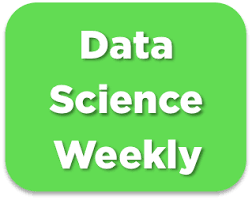

# Challenge : predict conversions 🏆🏆

This is the template that shows the different steps of the challenge. In this notebook, all the training/predictions steps are implemented for a very basic model (logistic regression with only one variable). Please use this template and feel free to change the preprocessing/training steps to get the model with the best f1-score ! May the force be with you 🧨🧨  

**For a detailed description of this project, please refer to *02-Conversion_rate_challenge.ipynb*.**

# Import libraries

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, confusion_matrix, precision_score, recall_score

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import GridSearchCV

from xgboost import XGBClassifier

import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
# setting Jedha color palette as default
pio.templates["jedha"] = go.layout.Template(
    layout_colorway=["#4B9AC7", "#4BE8E0", "#9DD4F3", "#97FBF6", "#2A7FAF", "#23B1AB", "#0E3449", "#015955"]
)
pio.templates.default = "jedha"
pio.renderers.default = "svg" # to be replaced by "iframe" if working on JULIE
from IPython.display import display

In [2]:
"""Fonction pour enregistrer les résultats"""
#on est très loin de MLFlow
import os

def ajouter_resultat(ligne):
    # Ajoute une ligne au fichier de résultats ; si le modèle existe déjà, sa ligne est remplacée.
    fichier = 'SHY_modeles_challenge.csv'
    nouvelle = pd.DataFrame([ligne])
    if os.path.exists(fichier):
        anciens = pd.read_csv(fichier)
        anciens = anciens[anciens['name'] != ligne['name']]
        nouvelle = pd.concat([anciens, nouvelle], ignore_index=True)
    nouvelle.to_csv(fichier, index=False)
    return nouvelle


# Read file with labels

In [3]:
data = pd.read_csv('conversion_data_train.csv')
print('Set with labels (our train+test) :', data.shape)

Set with labels (our train+test) : (284580, 6)


In [4]:
data.head()

,country,age,new_user,source,total_pages_visited,converted
0,China,22,1,Direct,2,0
1,UK,21,1,Ads,3,0
2,Germany,20,0,Seo,14,1
3,US,23,1,Seo,3,0
4,US,28,1,Direct,3,0


## Séparation train / test ##

In [5]:
target_variable = 'converted'

X = data.drop(columns=target_variable)
Y = data[target_variable]

data_train, data_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.10, random_state=0, stratify=Y)

print('Tailles : train', data_train.shape, 'et test', data_test.shape)
print('Proportion de convertis : train', round(Y_train.mean(), 4),
      'et test ', round(Y_test.mean(), 4))

Tailles : train (256122, 5) et test (28458, 5)
Proportion de convertis : train 0.0323 et test  0.0323


# EDA (exploration du jeu d'entraînement)
On explore uniquement le train, pour que les décisions de nettoyage ne dépendent pas du test.

In [6]:
# On explore le train seulement, avec la cible à côté des variables
eda = data_train.copy()
eda['converted'] = Y_train

print(eda.shape)
print()
print(eda.dtypes)
print()
print('Valeurs manquantes :')
print(eda.isna().sum())

(256122, 6)

country                  str
age                    int64
new_user               int64
source                   str
total_pages_visited    int64
converted              int64
dtype: object

Valeurs manquantes :
country                0
age                    0
new_user               0
source                 0
total_pages_visited    0
converted              0
dtype: int64


In [7]:
# Échantillon du train pour les graphiques
# Les statistiques (describe, value_counts, taux de conversion) se font sur tout le train.
eda_sample = eda.sample(10000, random_state=0)

In [8]:
eda.describe().round(2)

,age,new_user,total_pages_visited,converted
count,256122.00,256122.00,256122.00,256122.00
mean,30.56,0.69,4.87,0.03
std,8.27,0.46,3.34,0.18
min,17.00,0.00,1.00,0.00
25%,24.00,0.00,2.00,0.00
50%,30.00,1.00,4.00,0.00
75%,36.00,1.00,7.00,0.00
max,123.00,1.00,29.00,1.00


In [9]:
print(eda['country'].value_counts())
print()
print(eda['source'].value_counts())

country
US         144090
China       62240
UK          39274
Germany     10518
Name: count, dtype: int64

source
Seo       125536
Ads        71896
Direct     58690
Name: count, dtype: int64


In [10]:
# Focus sur age, car le max est à 123
print(eda['age'].sort_values(ascending=False).head(10))
print()
print('Nombre de lignes avec age > 80 :', (eda['age'] > 80).sum())
print('Nombre de lignes avec age < 15 :', (eda['age'] < 15).sum())

233196    123
11331     111
230590     79
268311     77
175251     73
104541     72
121537     70
113023     69
254852     68
111431     68
Name: age, dtype: int64

Nombre de lignes avec age > 80 : 2
Nombre de lignes avec age < 15 : 0


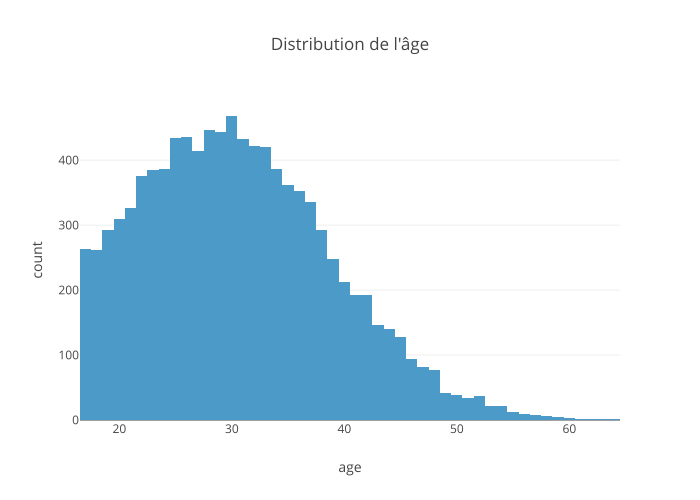

In [11]:
px.histogram(eda_sample, x='age', nbins=60, title="Distribution de l'âge")

EDA : taux de cconversion selon les variables catégorielles

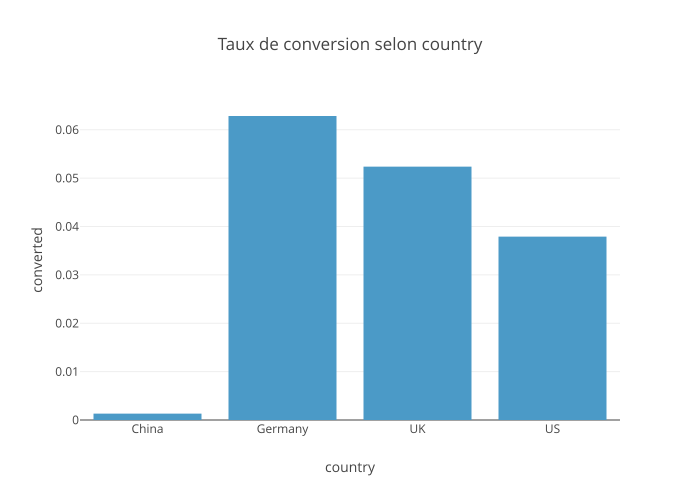

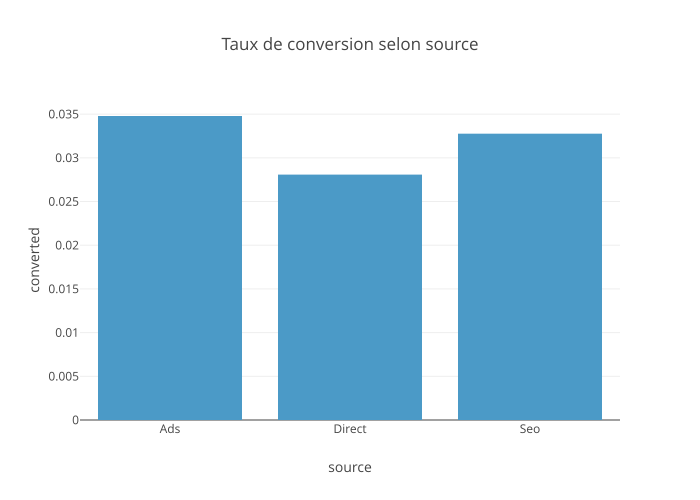

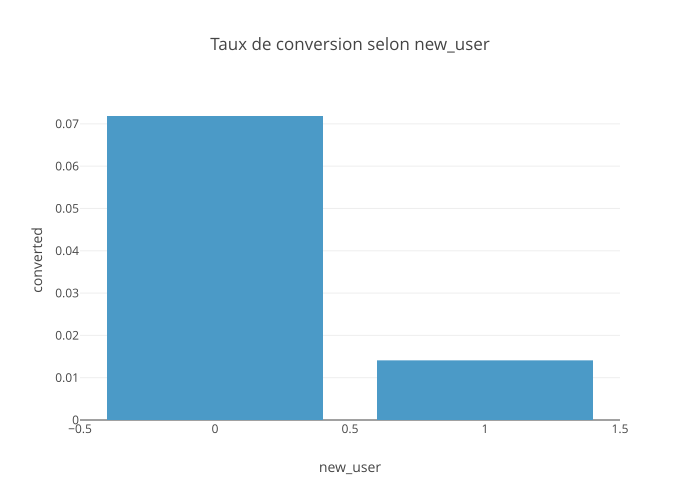

In [12]:
for colonne in ['country', 'source', 'new_user']:
    taux = eda.groupby(colonne)['converted'].mean().reset_index()
    fig = px.bar(taux, x=colonne, y='converted',
                 title=f'Taux de conversion selon {colonne}')
    fig.show()

A priori, la variable catégorielle ayant la plus grande incidence sur le taux de conversion est new_user. Le pays influe également, surtout la Chine qui semble à part. La source n'a pas l'air d'avoir trop d'incidence.

EDA : taux de conversion selon les variables numériques

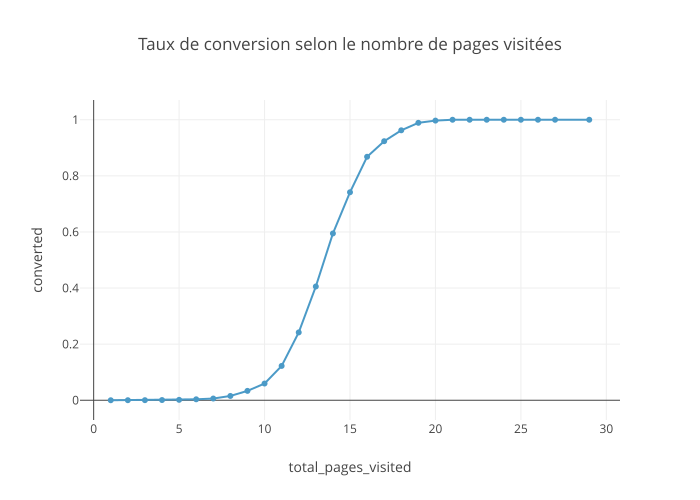

In [13]:
pages = eda.groupby('total_pages_visited')['converted'].mean().reset_index()

fig = px.line(pages, x='total_pages_visited', y='converted', markers=True,
              title='Taux de conversion selon le nombre de pages visitées')
fig.show()

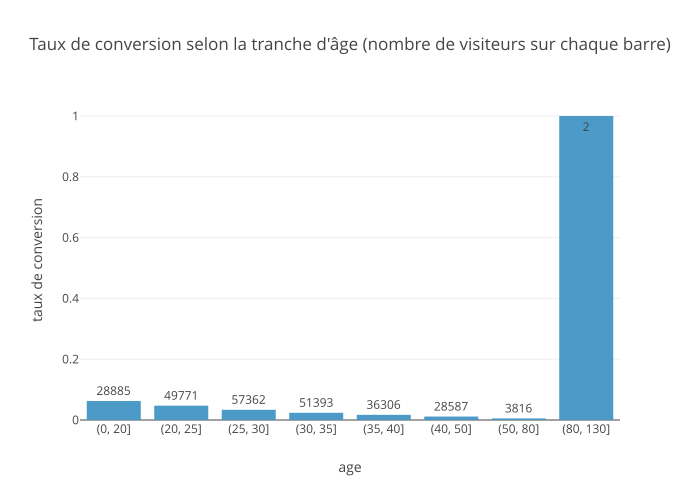

In [14]:
tranches = pd.cut(eda['age'], bins=[0, 20, 25, 30, 35, 40, 50, 80, 130])
age_tranche = (eda.groupby(tranches, observed=True)['converted']
                  .agg(['mean', 'count']).reset_index())
age_tranche['age'] = age_tranche['age'].astype(str)

fig = px.bar(age_tranche, x='age', y='mean', text='count',
             title="Taux de conversion selon la tranche d'âge (nombre de visiteurs sur chaque barre)",
             labels={'mean': 'taux de conversion'})
fig.show()

Pour les variables numériques, on constate que le taux de conversion décroit avec l'âge, et que les 2 âges supérieurs à 80 ans semblent aberrants --> à nettoyer.

Le taux de conversion en fonction du nombre de pages visitées forme une sigmoïde (presque trop parfaite...). Ce qui renforce l'idée d'une régression logistique.

## Nettoyage : âges
Dans le train, 2 lignes ont un âge supérieur à 100 ans (111 et 123 ans) et les 2 ont converti : ce sont des valeurs aberrantes. On retire les âges supérieurs à 100 ans.

In [15]:
print('Avant :', data_train.shape)
masque = data_train['age'] <= 100
data_train = data_train[masque]
Y_train = Y_train[masque]
print('Après :', data_train.shape)

Avant : (256122, 5)
Après : (256120, 5)


# Modèle M0 : baseline
Régression logistique avec une seule variable : total_pages_visited. Modèle de base fourni par le template.

In [16]:
# Choose variables to use in the model, and create train and test sets
features_list = ['total_pages_visited']
target_variable = 'converted'

X_train = data_train[features_list]
X_test = data_test[features_list]

print('Explanatory variables : ', X_train.columns)
print()

# ---- Training pipeline ----
# Put here all the preprocessings
print("Encoding categorical features and standardizing numerical features...")

featureencoder = StandardScaler()
X_train = featureencoder.fit_transform(X_train)
print("...Done")
print(X_train[0:5,:])

# Train model
print("Train model...")
classifier = LogisticRegression() # 
classifier.fit(X_train, Y_train)
print("...Done.")

# Predictions on training set
print("Predictions on training set...")
Y_train_pred = classifier.predict(X_train)
print("...Done.")
print(Y_train_pred)
print()

# ---- Test pipeline ----
# Use X_test, and the same preprocessings as in training pipeline, 
# but call "transform()" instead of "fit_transform" methods (see example below)

print("Encoding categorical features and standardizing numerical features...")

X_test = featureencoder.transform(X_test)
print("...Done")
print(X_test[0:5,:])

# Predictions on test set
print("Predictions on test set...")
Y_test_pred = classifier.predict(X_test)
print("...Done.")
print(Y_test_pred)
print()

# ---- Performance assessment ----
# WARNING : Use the same score as the one that will be used by Kaggle !
# Here, the f1-score will be used to assess the performances on the leaderboard
print("f1-score on train set : ", f1_score(Y_train, Y_train_pred))
print("f1-score on test set : ", f1_score(Y_test, Y_test_pred))

# You can also check more performance metrics to better understand what your model is doing
print("Confusion matrix on train set : ")
print(confusion_matrix(Y_train, Y_train_pred))
print()
print("Confusion matrix on test set : ")
print(confusion_matrix(Y_test, Y_test_pred))
print()

# Scores
f1_train = f1_score(Y_train, Y_train_pred)
f1_test = f1_score(Y_test, Y_test_pred)
precision_test = precision_score(Y_test, Y_test_pred)
recall_test = recall_score(Y_test, Y_test_pred)

# Ligne de M0 pour le tableau des résultats (enregistrée dans la cellule "Tableau des résultats")
resultat = {
    'name': 'M0_base',
    'characteristics': 'Régression logistique (paramètres par défaut), 1 variable : total_pages_visited, standardisée',
    'f1_train': f1_train,
    'f1_test': f1_test,
    'precision_test': precision_test,
    'recall_test': recall_test,
    'threshold': 0.5
}
# Enregistrement de la ligne du modèle dans le csv
ajouter_resultat(resultat)

# M0 sous forme de pipeline, pour pouvoir le réutiliser comme M1, M2 et M3 dans la section Prédictions
best_M0 = Pipeline([
    ('preprocessing', ColumnTransformer([('num', StandardScaler(), features_list)])),
    ('model', LogisticRegression())
])


Explanatory variables :  Index(['total_pages_visited'], dtype='str')

Encoding categorical features and standardizing numerical features...
...Done
[[-0.85939318]
 [-0.85939318]
 [ 0.6364286 ]
 [-0.56022883]
 [ 0.93559296]]
Train model...
...Done.
Predictions on training set...
...Done.
[0 0 0 ... 0 0 0]

Encoding categorical features and standardizing numerical features...
...Done
[[ 2.7305791 ]
 [ 0.03809989]
 [-0.26106447]
 [ 0.93559296]
 [-0.85939318]]
Predictions on test set...
...Done.
[1 0 0 ... 0 0 0]

f1-score on train set :  0.6971093422706326
f1-score on test set :  0.677195198989261
Confusion matrix on train set : 
[[246790   1070]
 [  3268   4992]]

Confusion matrix on test set : 
[[27411   129]
 [  382   536]]



Pour le modèle de base, M0, on obtient un f1_score de 0.677195 sur le test. 
(nb : ce score diffère du template car on a utilisé stratify dans la décomposition train / test)

# Modèle M1 : régression logistique avec toutes les variables

Régression logistique sans régularisation, sur les 5 variables : les variables numériques sont standardisées, les variables catégorielles (country, source) sont transformées en 0/1 (one-hot). Enfin un seuil de décision est réglé.

In [17]:
# On repart de data_train et data_test : toutes les variables (5 colonnes)
X_train = data_train
X_test = data_test

numeric_features = ['age', 'new_user', 'total_pages_visited']
categorical_features = ['country', 'source']

# Prétraitements : standardisation des numériques, one-hot des catégorielles
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(drop='first'), categorical_features)
])

# Régression logistique sans régularisation (C = infini)
model_M1 = Pipeline([
    ('preprocessing', preprocessor),
    ('model', LogisticRegression(C=np.inf))
])
model_M1.fit(X_train, Y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessing', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](5,)","['country','age','new_user','source','total_pages_visited']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,5
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining col

M1 - meilleur f1 = 0.7713, atteint pour le seuil 0.350


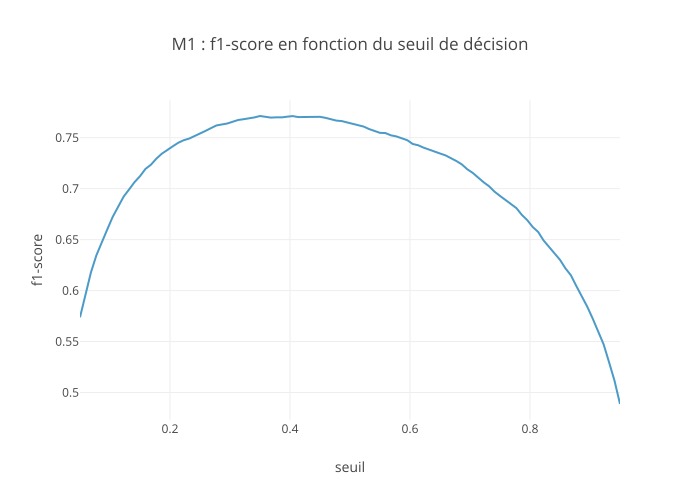

In [18]:
# choix du seuil de décision

y_proba = model_M1.predict_proba(X_train)[:, 1]

# threshold / seuil
seuils = np.linspace(0.05, 0.95, 100)
f1_scores = []

for seuil in seuils:
    y_pred = (y_proba >= seuil).astype(int)
    f1 = f1_score(Y_train, y_pred)
    f1_scores.append(f1)

best_index = np.argmax(f1_scores)
best_seuil = seuils[best_index]
best_f1 = f1_scores[best_index]

print(f"M1 - meilleur f1 = {best_f1:.4f}, atteint pour le seuil {best_seuil:.3f}")

fig = go.Figure()
fig.add_trace(
    go.Scatter(x=seuils, y=f1_scores, mode='lines')
)
fig.update_layout(title='M1 : f1-score en fonction du seuil de décision', xaxis_title='seuil', yaxis_title='f1-score')
fig.show()

pour ce modèle M1, le meilleur f1-score (sur le train) est obtenu pour le seuil de 0.350 (F1=0.7713).

In [19]:
#pour ce modèle M1, le meilleur f1-score (sur le train) est obtenu pour le seuil de 0.350 (F1=0.7713)
threshold_M1 = 0.350

#Entrainement final sur l'ensemble du train, et calcul des scores
Y_train_pred_M1 = model_M1.predict_proba(X_train)[:, 1] >= threshold_M1
f1_train_M1 = f1_score(Y_train, Y_train_pred_M1)
print('f1-score train (avec seuil) :', round(f1_train_M1, 4))

Y_test_pred_sans_seuil_M1 = model_M1.predict(X_test)
Y_test_pred_M1 = model_M1.predict_proba(X_test)[:, 1] >= threshold_M1

f1_test_sans_seuil_M1 = f1_score(Y_test, Y_test_pred_sans_seuil_M1)
f1_test_M1 = f1_score(Y_test, Y_test_pred_M1)
precision_test_M1 = precision_score(Y_test, Y_test_pred_M1)
recall_test_M1 = recall_score(Y_test, Y_test_pred_M1)

print(f"f1-score test, seuil 0.5 (sans seuil) : {round(f1_test_sans_seuil_M1, 4)}")
print(f"f1-score test, seuil {round(threshold_M1, 2)} : {round(f1_test_M1, 4)}")

resultat = {
    'name': 'M1_logreg_seuil',
    'characteristics': 'Régression logistique sans régularisation (C=inf), 5 variables (age, new_user, total_pages_visited standardisées ; country, source en one-hot)',
    'f1_train': f1_train_M1,
    'f1_test_sans_seuil': f1_test_sans_seuil_M1,
    'f1_test': f1_test_M1,
    'precision_test': precision_test_M1,
    'recall_test': recall_test_M1,
    'threshold': threshold_M1,
}
# Enregistrement de la ligne du modèle dans le csv
ajouter_resultat(resultat)

f1-score train (avec seuil) : 0.7713
f1-score test, seuil 0.5 (sans seuil) : 0.7603
f1-score test, seuil 0.35 : 0.7586


,name,characteristics,f1_train,f1_test,precision_test,recall_test,threshold,f1_test_sans_seuil
0,M0_base,"Régression logistique (paramètres par défaut),...",0.697109,0.677195,0.806015,0.583878,0.50,NaN
1,M1_logreg_seuil,Régression logistique sans régularisation (C=i...,0.771272,0.758583,0.771396,0.746187,0.35,0.760291


# Modèle M2 : régression logistique avec régularisation Ridge

Même modèle que M1, avec une pénalité L2 (Ridge). Le paramètre de régularisation C est choisi par validation croisée (le préprocesseur est celui de M1). Enfin un seuil de décision est réglé.

In [20]:
# On repart de data_train et data_test : toutes les variables (5 colonnes)
X_train = data_train
X_test = data_test

#choix de l'hyperparamètre de régularisation Ridge
pipeline_M2 = Pipeline([
    ('preprocessing', preprocessor),
    ('model', LogisticRegression())  # pénalité L2 (Ridge) par défaut
])

grid_M2 = GridSearchCV(pipeline_M2, param_grid={'model__C': [0.01, 0.1, 1, 10, 100]},
                       cv=5, scoring='f1')
grid_M2.fit(X_train, Y_train)

print("f1 moyen en validation croisée pour chaque C :")
for C_value, score in zip(grid_M2.cv_results_['param_model__C'], grid_M2.cv_results_['mean_test_score']):
    print(f"  C = {C_value} : {round(score, 4)}")
print(f"Meilleur C : {grid_M2.best_params_['model__C']} -> f1-score : {round(grid_M2.best_score_, 5)}")

f1 moyen en validation croisée pour chaque C :
  C = 0.01 : 0.7503
  C = 0.1 : 0.7623
  C = 1.0 : 0.7641
  C = 10.0 : 0.765
  C = 100.0 : 0.765
Meilleur C : 100 -> f1-score : 0.76503


M2 - meilleur f1 = 0.7713, atteint pour le seuil 0.350


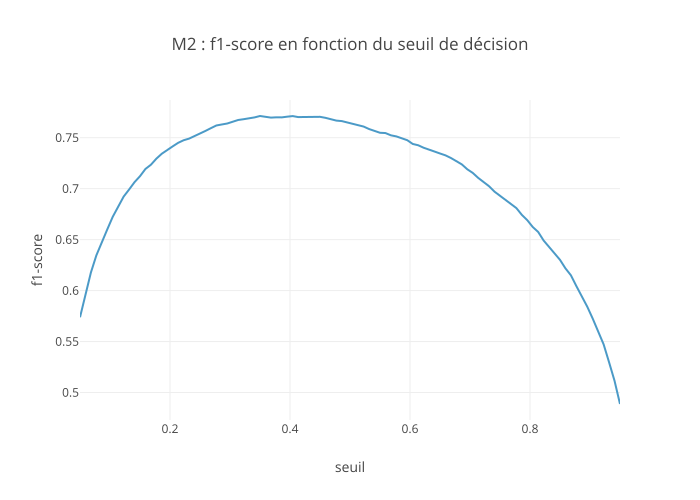

In [21]:
# on note que le meilleur C vaut 100 pour un F1-score associé de 0.76503
# choix du seuil de décision

best_M2 = grid_M2.best_estimator_

y_proba = best_M2.predict_proba(X_train)[:, 1]

# threshold / seuil
seuils = np.linspace(0.05, 0.95, 100)
f1_scores = []

for seuil in seuils:
    y_pred = (y_proba >= seuil).astype(int)
    f1 = f1_score(Y_train, y_pred)
    f1_scores.append(f1)

best_index = np.argmax(f1_scores)
best_seuil = seuils[best_index]
best_f1 = f1_scores[best_index]

print(f"M2 - meilleur f1 = {best_f1:.4f}, atteint pour le seuil {best_seuil:.3f}")

fig = go.Figure()
fig.add_trace(
    go.Scatter(x=seuils, y=f1_scores, mode='lines')
)
fig.update_layout(title='M2 : f1-score en fonction du seuil de décision', xaxis_title='seuil', yaxis_title='f1-score')
fig.show()

pour ce modèle M2, le meilleur f1-score (sur le train) est obtenu pour le seuil de 0.350 (F1=0.7713). Le score sans seuil est de 0.76503.

In [22]:
#pour ce modèle M2, le meilleur f1-score (sur le train) est obtenu pour le seuil de 0.350 (F1=0.7713)
threshold_M2 = 0.350

#Entrainement final sur l'ensemble du train, et calcul des scores
Y_train_pred_M2 = best_M2.predict_proba(X_train)[:, 1] >= threshold_M2
f1_train_M2 = f1_score(Y_train, Y_train_pred_M2)
print('f1-score train (avec seuil) :', round(f1_train_M2, 4))

Y_test_pred_sans_seuil_M2 = best_M2.predict(X_test)
Y_test_pred_M2 = best_M2.predict_proba(X_test)[:, 1] >= threshold_M2

f1_test_sans_seuil_M2 = f1_score(Y_test, Y_test_pred_sans_seuil_M2)
f1_test_M2 = f1_score(Y_test, Y_test_pred_M2)
precision_test_M2 = precision_score(Y_test, Y_test_pred_M2)
recall_test_M2 = recall_score(Y_test, Y_test_pred_M2)

print(f"f1-score test, seuil 0.5 (sans seuil) : {round(f1_test_sans_seuil_M2, 4)}")
print(f"f1-score test, seuil {round(threshold_M2, 2)} : {round(f1_test_M2, 4)}")

resultat = {
    'name': 'M2_logreg_ridge_seuil',
    'characteristics': 'Régression logistique L2 (Ridge), C=' + str(grid_M2.best_params_['model__C']) + ', 5 variables (age, new_user, total_pages_visited standardisées ; country, source en one-hot)',
    'f1_train': f1_train_M2,
    'f1_test_sans_seuil': f1_test_sans_seuil_M2,
    'f1_test': f1_test_M2,
    'precision_test': precision_test_M2,
    'recall_test': recall_test_M2,
    'threshold': threshold_M2,

}
# Enregistrement de la ligne du modèle dans le csv
ajouter_resultat(resultat)

f1-score train (avec seuil) : 0.7713
f1-score test, seuil 0.5 (sans seuil) : 0.7603
f1-score test, seuil 0.35 : 0.7586


,name,characteristics,f1_train,f1_test,precision_test,recall_test,threshold,f1_test_sans_seuil
0,M0_base,"Régression logistique (paramètres par défaut),...",0.697109,0.677195,0.806015,0.583878,0.50,NaN
1,M1_logreg_seuil,Régression logistique sans régularisation (C=i...,0.771272,0.758583,0.771396,0.746187,0.35,0.760291
2,M2_logreg_ridge_seuil,"Régression logistique L2 (Ridge), C=100, 5 var...",0.771272,0.758583,0.771396,0.746187,0.35,0.760291


# Modèle M3 : XGBoost

XGBoost (arbres de décision boostés), sur les 5 variables, avec le même préprocesseur que M1 et M2. Les hyperparamètres `max_depth` et `n_estimators` sont choisis par validation croisée. Enfin un seuil de décision est réglé.

In [23]:
# On repart de data_train et data_test : toutes les variables (5 colonnes)
X_train = data_train
X_test = data_test

# Les arbres n'ont pas besoin de standardisation (sans conséquence ici) ; le one-hot de country et source est nécessaire
pipeline_M3 = Pipeline([
    ('preprocessing', preprocessor),
    ('model', XGBClassifier(random_state=0))
])

grid_M3 = GridSearchCV(pipeline_M3, param_grid={'model__max_depth': [2, 4, 6],
                                                'model__n_estimators': [50, 100, 200]},
                       cv=5, scoring='f1')
grid_M3.fit(X_train, Y_train)

print("f1 moyen en validation croisée pour chaque combinaison :")
for params, score in zip(grid_M3.cv_results_['params'], grid_M3.cv_results_['mean_test_score']):
    print(f"  {params} : {round(score, 4)}")
print(f"Meilleurs paramètres : {grid_M3.best_params_} -> f1-score : {round(grid_M3.best_score_, 5)}")

f1 moyen en validation croisée pour chaque combinaison :
  {'model__max_depth': 2, 'model__n_estimators': 50} : 0.7575
  {'model__max_depth': 2, 'model__n_estimators': 100} : 0.7602
  {'model__max_depth': 2, 'model__n_estimators': 200} : 0.7625
  {'model__max_depth': 4, 'model__n_estimators': 50} : 0.7639
  {'model__max_depth': 4, 'model__n_estimators': 100} : 0.7622
  {'model__max_depth': 4, 'model__n_estimators': 200} : 0.7606
  {'model__max_depth': 6, 'model__n_estimators': 50} : 0.7614
  {'model__max_depth': 6, 'model__n_estimators': 100} : 0.7587
  {'model__max_depth': 6, 'model__n_estimators': 200} : 0.7553
Meilleurs paramètres : {'model__max_depth': 4, 'model__n_estimators': 50} -> f1-score : 0.76394


M3 - meilleur f1 = 0.7706, atteint pour le seuil 0.441


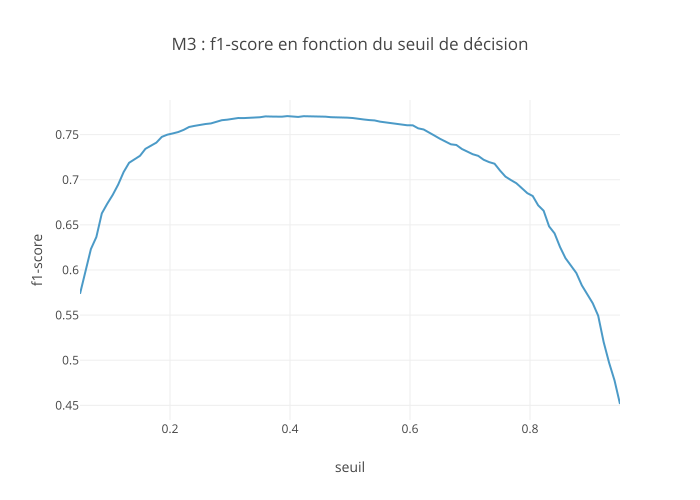

In [24]:
#choix du seuil

best_M3 = grid_M3.best_estimator_

y_proba = best_M3.predict_proba(X_train)[:, 1]

# threshold / seuil
seuils = np.linspace(0.05, 0.95, 100)
f1_scores = []

for seuil in seuils:
    y_pred = (y_proba >= seuil).astype(int)
    f1 = f1_score(Y_train, y_pred)
    f1_scores.append(f1)

best_index = np.argmax(f1_scores)
best_seuil = seuils[best_index]
best_f1 = f1_scores[best_index]

print(f"M3 - meilleur f1 = {best_f1:.4f}, atteint pour le seuil {best_seuil:.3f}")

fig = go.Figure()
fig.add_trace(go.Scatter(x=seuils, y=f1_scores, mode='lines'))
fig.update_layout(title='M3 : f1-score en fonction du seuil de décision', xaxis_title='seuil', yaxis_title='f1-score')
fig.show()

In [25]:
# seuil trouvé dans la cellule précédente
threshold_M3 = round(best_seuil, 3)

f1_train_M3 = f1_score(Y_train, best_M3.predict_proba(X_train)[:, 1] >= threshold_M3)
print('f1-score train (avec seuil) :', round(f1_train_M3, 4))

Y_test_pred_sans_seuil_M3 = best_M3.predict(X_test)
Y_test_pred_M3 = best_M3.predict_proba(X_test)[:, 1] >= threshold_M3

f1_test_sans_seuil_M3 = f1_score(Y_test, Y_test_pred_sans_seuil_M3)
f1_test_M3 = f1_score(Y_test, Y_test_pred_M3)
precision_test_M3 = precision_score(Y_test, Y_test_pred_M3)
recall_test_M3 = recall_score(Y_test, Y_test_pred_M3)

print(f"f1-score test, seuil 0.5 (sans seuil) : {round(f1_test_sans_seuil_M3, 4)}")
print(f"f1-score test, seuil {round(threshold_M3, 2)} : {round(f1_test_M3, 4)}")

resultat = {
    'name': 'M3_xgboost_seuil',
    'characteristics': 'XGBoost, ' + str(grid_M3.best_params_) + ', 5 variables (age, new_user, total_pages_visited standardisées ; country, source en one-hot)',
    'f1_train': f1_train_M3,
    'f1_test_sans_seuil': f1_test_sans_seuil_M3,
    'f1_test': f1_test_M3,
    'precision_test': precision_test_M3,
    'recall_test': recall_test_M3,
    'threshold': threshold_M3,
}
# Enregistrement de la ligne du modèle dans le csv
ajouter_resultat(resultat)

f1-score train (avec seuil) : 0.7706
f1-score test, seuil 0.5 (sans seuil) : 0.7585
f1-score test, seuil 0.44 : 0.7566


,name,characteristics,f1_train,f1_test,precision_test,recall_test,threshold,f1_test_sans_seuil
0,M0_base,"Régression logistique (paramètres par défaut),...",0.697109,0.677195,0.806015,0.583878,0.500,NaN
1,M1_logreg_seuil,Régression logistique sans régularisation (C=i...,0.771272,0.758583,0.771396,0.746187,0.350,0.760291
2,M2_logreg_ridge_seuil,"Régression logistique L2 (Ridge), C=100, 5 var...",0.771272,0.758583,0.771396,0.746187,0.350,0.760291
3,M3_xgboost_seuil,"XGBoost, {'model__max_depth': 4, 'model__n_est...",0.770613,0.756567,0.815094,0.705882,0.441,0.758497


# Comparaison des modèles

| Modèle | Description | F1 train | F1 test sans seuil | F1 test (avec seuil) | Precision test | Recall test | Seuil |
|---|---|---|---|---|---|---|---|
| M0 | Régression logistique, 1 variable (`total_pages_visited`) | 0.697 | – | 0.677 | 0.806 | 0.584 | 0.50 |
| M1 | Régression logistique, 5 variables, sans régularisation | 0.771 | 0.760 | 0.759 | 0.771 | 0.746 | 0.35 |
| M2 | Régression logistique Ridge (C=100), 5 variables | 0.771 | 0.760 | 0.759 | 0.771 | 0.746 | 0.35 |
| M3 | XGBoost (max_depth=4, n_estimators=50), 5 variables | 0.771 | 0.758 | 0.757 | 0.815 | 0.706 | 0.44 |

## Ce que l'on observe

1. Les variables supplémentaires aident beaucoup. Passer de 1 variable (M0) à 5 variables (M1) fait monter le F1 test de 0.677 à 0.759. Le recall passe de 0.58 à 0.75 : on détecte beaucoup plus de conversions.
2. La régularisation ne sert à rien ici. M1 (sans régularisation) et M2 (Ridge) donnent exactement les mêmes scores. Le meilleur C trouvé est 100, c'est-à-dire une régularisation quasi nulle. Avec seulement 5 variables et plus de 280 000 lignes, le modèle n'a pas de risque de surapprentissage à corriger.
3. XGBoost ne fait pas mieux que la régression logistique. Son F1 test (0.757) est très proche de celui de M1 (0.759). La différence (environ 0.002) est trop petite pour être significative. Ce modèle plus complexe n'apporte donc rien ici.
4. M3 et M1 ne se trompent pas de la même façon. XGBoost est plus précis (0.815 contre 0.771) mais détecte moins de conversions (recall 0.706 contre 0.746). Le choix dépend de ce qui coûte le plus cher : une fausse alerte ou une conversion manquée.
5. Le seuil change peu le F1 test. Avec ou sans seuil, les scores diffèrent d'environ 0.002 (par exemple 0.760 sans seuil et 0.759 avec pour M1). Le seuil ajuste surtout l'équilibre entre precision et recall.
6. Pas de surapprentissage. L'écart entre F1 train et F1 test est d'environ 0.013 pour M1 et M2, et de 0.014 pour M3, ce qui est faible.

## Choix du modèle final

Les F1 test de M1, M2 et M3 sont équivalents. Je choisis donc le modèle le plus simple et le plus interprétable : la régression logistique (M1). Ses coefficients permettent d'expliquer l'effet de chaque variable, ce qui est utile pour des recommandations au marketing. Elle ne demande aucun réglage de régularisation.

In [26]:
resultats = pd.read_csv('SHY_modeles_challenge.csv')

# On trie du meilleur au moins bon F1 test (kind='stable' : en cas d'égalité, on garde l'ordre du fichier)
resultats = resultats.sort_values('f1_test', ascending=False, kind='stable')
print(resultats[['name', 'f1_test']])

# Le nom complet est par exemple 'M1_logreg_seuil' : on garde la partie avant le premier '_'
best_model = resultats.iloc[0]['name'].split('_')[0]
print("Meilleur modèle :", best_model)

                    name   f1_test
1        M1_logreg_seuil  0.758583
2  M2_logreg_ridge_seuil  0.758583
3       M3_xgboost_seuil  0.756567
0                M0_base  0.677195
Meilleur modèle : M1


# Prédictions sur conversion_data_test.csv
On ré-entraîne le modèle choisi sur toutes les données avec cibles (train + test), puis on prédit le fichier sans cibles.


In [27]:
# Dictionnaire : pour chaque nom de modèle, son pipeline et son seuil
modeles = {
    'M0': (best_M0, 0.5),
    'M1': (model_M1, threshold_M1),
    'M2': (best_M2, threshold_M2),
    'M3': (best_M3, threshold_M3),
}

# On retrouve le modèle et le seuil à partir du texte best_model (ex. 'M1')
modele_final, seuil_final = modeles[best_model]
print('Modèle utilisé :', best_model, '| seuil :', seuil_final)

# Ré-entraînement sur toutes les lignes de conversion_data_train.csv
modele_final.fit(X, Y)

# Lecture du fichier sans cibles (le pipeline refait tout seul les prétraitements)
data_without_labels = pd.read_csv('conversion_data_test.csv')
print('Jeu sans cibles :', data_without_labels.shape)


Modèle utilisé : M1 | seuil : 0.35
Jeu sans cibles : (31620, 5)


In [28]:
# ATTENTION : fichier CSV avec une seule colonne 'converted', sans index
# Nom du fichier : conversion_data_test_predictions_[equipe]-[modele].csv
proba = modele_final.predict_proba(data_without_labels)[:, 1]
Y_predictions = pd.DataFrame({'converted': (proba >= seuil_final).astype(int)})
Y_predictions.to_csv(f'conversion_data_test_predictions_Sandrine-{best_model}.csv', index=False)
print(Y_predictions['converted'].value_counts())


converted
0    30648
1      972
Name: count, dtype: int64
